# 04 — Panel Model: Net Energy Position → Reserve Currency Share

Runs stationarity tests, pooled time series model at lag 10 and 15, robustness checks, and per-country VECM/VAR.

In [1]:
import sys
sys.path.append('../src')
from models import (run_stationarity_battery, run_both_lags,
                    run_robustness_checks, run_vecm_or_var,
                    run_tmpi_cross_section)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Load model-ready panel
panel = pd.read_csv('../data/processed/panel_model_ready.csv')
print(f"Panel: {panel.shape}")

# Reserve currency sub-panel for main model
reserve_panel = panel[panel['has_reserve_share'] == True].copy()
print(f"Reserve currency panel: {reserve_panel.shape}")
print(f"Entities: {sorted(reserve_panel['country_code'].unique())}")
print(f"Years: {reserve_panel['year'].min()}\u2013{reserve_panel['year'].max()}")

Panel: (12109, 34)
Reserve currency panel: (129, 34)
Entities: ['CHE', 'CHN', 'GBR', 'JPN', 'USA']
Years: 1995–2024


## Step 0: Stationarity Tests

MUST run before any regression. Non-stationary series produce spurious results. ADF null = has unit root. KPSS null = stationary. If both I(1): test for cointegration before regression.

In [2]:
stat_vars = ['reserve_share', 'net_energy_position', 'gdp_share',
             'trade_openness', 'inflation_cpi']
available_stat = [v for v in stat_vars if v in reserve_panel.columns]

stationarity_results = run_stationarity_battery(reserve_panel, variables=available_stat)
stationarity_results

CHE:reserve_share: NON-STATIONARY I(1) — difference before modelling (ADF p=0.054, KPSS p=0.043)
CHE:net_energy_position: STATIONARY I(0) (ADF p=0.000, KPSS p=0.100)
CHE:gdp_share: STATIONARY I(0) (ADF p=0.001, KPSS p=0.100)
CHE:trade_openness: NON-STATIONARY I(1) — difference before modelling (ADF p=0.677, KPSS p=0.010)
CHE:inflation_cpi: STATIONARY I(0) (ADF p=0.011, KPSS p=0.100)
GBR:reserve_share: NON-STATIONARY I(1) — difference before modelling (ADF p=0.100, KPSS p=0.029)
GBR:net_energy_position: NON-STATIONARY I(1) — difference before modelling (ADF p=0.552, KPSS p=0.010)
GBR:gdp_share: NON-STATIONARY I(1) — difference before modelling (ADF p=0.723, KPSS p=0.018)
GBR:trade_openness: NON-STATIONARY I(1) — difference before modelling (ADF p=0.937, KPSS p=0.010)
GBR:inflation_cpi: INCONCLUSIVE — possibly I(2) or structural break (ADF p=0.086, KPSS p=0.100)
JPN:reserve_share: INCONCLUSIVE — possibly I(2) or structural break (ADF p=0.324, KPSS p=0.100)
JPN:net_energy_position: STATIO

,series,n_obs,adf_stat,adf_pval,adf_reject_unit_root,kpss_stat,kpss_pval,kpss_reject_stationarity,conclusion,country
0,CHE:reserve_share,30,-2.8318,0.0539,False,0.4923,0.0434,True,NON-STATIONARY I(1) — difference before modelling,CHE
1,CHE:net_energy_position,30,-5.0346,0.0000,True,0.2715,0.1000,False,STATIONARY I(0),CHE
2,CHE:gdp_share,29,-4.1184,0.0009,True,0.3285,0.1000,False,STATIONARY I(0),CHE
3,CHE:trade_openness,29,-1.1920,0.6770,False,0.7960,0.0100,True,NON-STATIONARY I(1) — difference before modelling,CHE
4,CHE:inflation_cpi,29,-3.4079,0.0107,True,0.1896,0.1000,False,STATIONARY I(0),CHE
5,GBR:reserve_share,30,-2.5680,0.0998,False,0.5583,0.0285,True,NON-STATIONARY I(1) — difference before modelling,GBR
6,GBR:net_energy_position,30,-1.4630,0.5517,False,0.7746,0.0100,True,NON-STATIONARY I(1) — difference before modelling,GBR
7,GBR:gdp_share,29,-1.0790,0.7234,False,0.6537,0.0178,True,NON-STATIONARY I(1) — difference before modelling,GBR
8,GBR:trade_openness,29,-0.2140,0.9368,False,0.7783,0.0100,True,NON-STATIONARY I(1) — difference before modelling,GBR
9,GBR:inflation_cpi,29,-2.6374,0.0855,False,0.2551,0.1000,False,INCONCLUSIVE — possibly I(2) or structural break,GBR


## Step 1: Pooled Time Series — Levels Specification

Run if majority of series are I(0). With N=6 entities, results are structured descriptive rather than causal identification. HC3 robust standard errors.

In [3]:
results_levels = run_both_lags(reserve_panel, differenced=False)


=== POOLED TS MODEL (lag=10yr, levels) ===
N observations: 123
N entities: 5
NEP coefficient: 85.4330 (p=0.023)
R²: 0.997

=== POOLED TS MODEL (lag=15yr, levels) ===
N observations: 123
N entities: 5
NEP coefficient: 105.6546 (p=0.005)
R²: 0.998

=== LAG COMPARISON ===
Lag      NEP coef     p-value    R²       N
10       85.4330      0.023      0.997    123
15       105.6546     0.005      0.998    123


## Step 2: Pooled Time Series — Differenced Specification

Run if majority of series are I(1). First-differencing removes unit roots but also removes long-run information. Compare to levels spec — if both show consistent sign, finding is robust.

In [4]:
results_diff = run_both_lags(reserve_panel, differenced=True)


=== POOLED TS MODEL (lag=10yr, differenced) ===
N observations: 118
N entities: 5
NEP coefficient: 59.7913 (p=0.196)
R²: 0.366

=== POOLED TS MODEL (lag=15yr, differenced) ===
N observations: 118
N entities: 5
NEP coefficient: -5.9710 (p=0.875)
R²: 0.347

=== LAG COMPARISON ===
Lag      NEP coef     p-value    R²       N
10       59.7913      0.196      0.366    118
15       -5.9710      0.875      0.347    118


## Step 3: Robustness Check — 2×2 Specification Table

4/4 significant = robust. 2-3/4 = fragile, interpret cautiously. <2/4 = not robust. Report all four specifications in the paper — never cherry-pick.

In [5]:
robustness = run_robustness_checks(reserve_panel)
robustness['summary']


=== POOLED TS MODEL (lag=10yr, levels) ===
N observations: 123
N entities: 5
NEP coefficient: 85.4330 (p=0.023)
R²: 0.997

=== POOLED TS MODEL (lag=15yr, levels) ===
N observations: 123
N entities: 5
NEP coefficient: 105.6546 (p=0.005)
R²: 0.998

=== POOLED TS MODEL (lag=10yr, differenced) ===
N observations: 118
N entities: 5
NEP coefficient: 59.7913 (p=0.196)
R²: 0.366

=== POOLED TS MODEL (lag=15yr, differenced) ===
N observations: 118
N entities: 5
NEP coefficient: -5.9710 (p=0.875)
R²: 0.347

=== ROBUSTNESS CHECK — 2×2 SPECIFICATION TABLE ===
specification  nep_coef  nep_pval  r_squared  n_obs  significant_05
 levels_lag10   85.4330     0.023      0.997    123            True
 levels_lag15  105.6546     0.005      0.998    123            True
   diff_lag10   59.7913     0.196      0.366    118           False
   diff_lag15   -5.9710     0.875      0.347    118           False

2/4 specifications significant at 5%.
Finding: FRAGILE — significant in some but not all specs. Interpre

,specification,nep_coef,nep_pval,r_squared,n_obs,significant_05
0,levels_lag10,85.4330,0.023,0.997,123,True
1,levels_lag15,105.6546,0.005,0.998,123,True
2,diff_lag10,59.7913,0.196,0.366,118,False
3,diff_lag15,-5.9710,0.875,0.347,118,False


## Step 4: Export Regression Table

In [6]:
import os
os.makedirs('../outputs/tables/', exist_ok=True)

rows = []
for spec_key, r in robustness['results'].items():
    lag_n = 10 if 'lag10' in spec_key else 15
    diff = 'diff' in spec_key
    nep_col = f"{'d_' if diff else ''}net_energy_position_lag{lag_n}"

    if nep_col in r['coefficients'].index:
        rows.append({
            'Specification': spec_key,
            'NEP lag (yr)': lag_n,
            'Differenced': diff,
            '\u03b2 (NEP)': round(r['coefficients'][nep_col], 4),
            'SE': round(r['model'].bse.get(nep_col, float('nan')), 4),
            'p-value': round(r['pvalues'][nep_col], 3),
            'R\u00b2': round(r['r_squared'], 3),
            'N obs': r['n_obs'],
            'Significant': r['pvalues'][nep_col] < 0.05,
        })

results_table = pd.DataFrame(rows)
print(results_table.to_string(index=False))

# Save
results_table.to_csv('../outputs/tables/main_results.csv', index=False)
print("\nSaved: ../outputs/tables/main_results.csv")
results_table

Specification  NEP lag (yr)  Differenced  β (NEP)      SE  p-value    R²  N obs  Significant
 levels_lag10            10        False  85.4330 37.5440    0.023 0.997    123         True
 levels_lag15            15        False 105.6546 37.4707    0.005 0.998    123         True
   diff_lag10            10         True  59.7913 46.2030    0.196 0.366    118        False
   diff_lag15            15         True  -5.9710 37.8168    0.875 0.347    118        False

Saved: ../outputs/tables/main_results.csv


,Specification,NEP lag (yr),Differenced,β (NEP),SE,p-value,R²,N obs,Significant
0,levels_lag10,10,False,85.4330,37.5440,0.023,0.997,123,True
1,levels_lag15,15,False,105.6546,37.4707,0.005,0.998,123,True
2,diff_lag10,10,True,59.7913,46.2030,0.196,0.366,118,False
3,diff_lag15,15,True,-5.9710,37.8168,0.875,0.347,118,False


## Step 5: VECM/VAR — Focal Country Time Series

Per-country analysis. Tests whether energy position and reserve share share a long-run equilibrium (cointegrated) or not. Granger causality tests direction: does energy position *cause* reserve share, or the reverse?

In [7]:
vecm_results = {}
for country in ['CHN', 'IND', 'RUS', 'JPN']:
    print(f"\n{'='*50}")
    print(f"Country: {country}")
    print('='*50)
    result = run_vecm_or_var(panel, country=country)
    vecm_results[country] = result


Country: CHN

Country: IND

Country: RUS

Country: JPN
JPN:net_energy_position: STATIONARY I(0) (ADF p=0.000, KPSS p=0.093)
JPN:reserve_share: INCONCLUSIVE — possibly I(2) or structural break (ADF p=0.324, KPSS p=0.100)
JPN: Mixed stationarity — running VAR in levels


## Step 6: Granger Causality Summary

In [8]:
granger_rows = []
for country, r in vecm_results.items():
    if 'error' in r:
        granger_rows.append({'Country': country, 'Model': 'ERROR',
                              'NEP\u2192Reserve p': None, 'Reserve\u2192NEP p': None,
                              'Interpretation': r['error']})
        continue

    model_type = r.get('model_type', 'unknown')

    if model_type == 'VECM':
        granger_rows.append({
            'Country': country,
            'Model': 'VECM',
            'Long-run \u03b2 (NEP)': str(r.get('beta', 'see result')),
            'Speed of adj (\u03b1)': str(r.get('alpha', 'see result')),
            'Interpretation': 'Long-run cointegrating relationship found'
        })
    elif 'granger' in r:
        gc = r['granger']
        nep_causes = gc.get('reserve_share_causes_net_energy_position',
                    gc.get('reserve_share_causes_reserve_share', {}))
        res_causes = gc.get('net_energy_position_causes_reserve_share', {})

        nep_p = min(nep_causes.values()) if nep_causes else None
        res_p = min(res_causes.values()) if res_causes else None

        granger_rows.append({
            'Country': country,
            'Model': model_type,
            'NEP\u2192Reserve p': round(nep_p, 3) if nep_p else None,
            'Reserve\u2192NEP p': round(res_p, 3) if res_p else None,
            'Interpretation': (
                'NEP Granger-causes Reserve' if (nep_p and nep_p < 0.05)
                else 'No Granger causality at 5%'
            )
        })

granger_df = pd.DataFrame(granger_rows)
print(granger_df.to_string(index=False))
granger_df.to_csv('../outputs/tables/granger_results.csv', index=False)
granger_df

Country Model NEP→Reserve p Reserve→NEP p                   Interpretation
    CHN ERROR          None          None Insufficient data for CHN: 9 obs
    IND ERROR          None          None Insufficient data for IND: 0 obs
    RUS ERROR          None          None Insufficient data for RUS: 0 obs


,Country,Model,NEP→Reserve p,Reserve→NEP p,Interpretation
0,CHN,ERROR,None,None,Insufficient data for CHN: 9 obs
1,IND,ERROR,None,None,Insufficient data for IND: 0 obs
2,RUS,ERROR,None,None,Insufficient data for RUS: 0 obs


## Step 7: Coefficient Plot

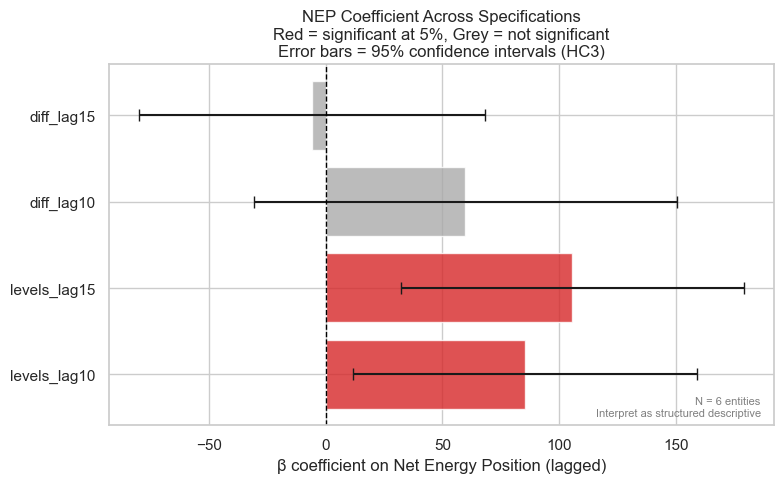

In [9]:
if len(results_table) > 0 and '\u03b2 (NEP)' in results_table.columns:
    fig, ax = plt.subplots(figsize=(8, 5))

    specs = results_table['Specification']
    coefs = results_table['\u03b2 (NEP)']
    ses = results_table['SE']
    sig = results_table['Significant']

    colors = ['#d62728' if s else '#aaaaaa' for s in sig]

    ax.barh(specs, coefs, xerr=1.96*ses, color=colors, alpha=0.8,
            error_kw={'linewidth': 1.5, 'capsize': 4})
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('\u03b2 coefficient on Net Energy Position (lagged)')
    ax.set_title('NEP Coefficient Across Specifications\n'
                 'Red = significant at 5%, Grey = not significant\n'
                 'Error bars = 95% confidence intervals (HC3)')
    ax.text(0.98, 0.02, 'N = 6 entities\nInterpret as structured descriptive',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')
    plt.tight_layout()
    plt.savefig('../outputs/figures/coefficient_plot.png', dpi=150, bbox_inches='tight')
    plt.show()